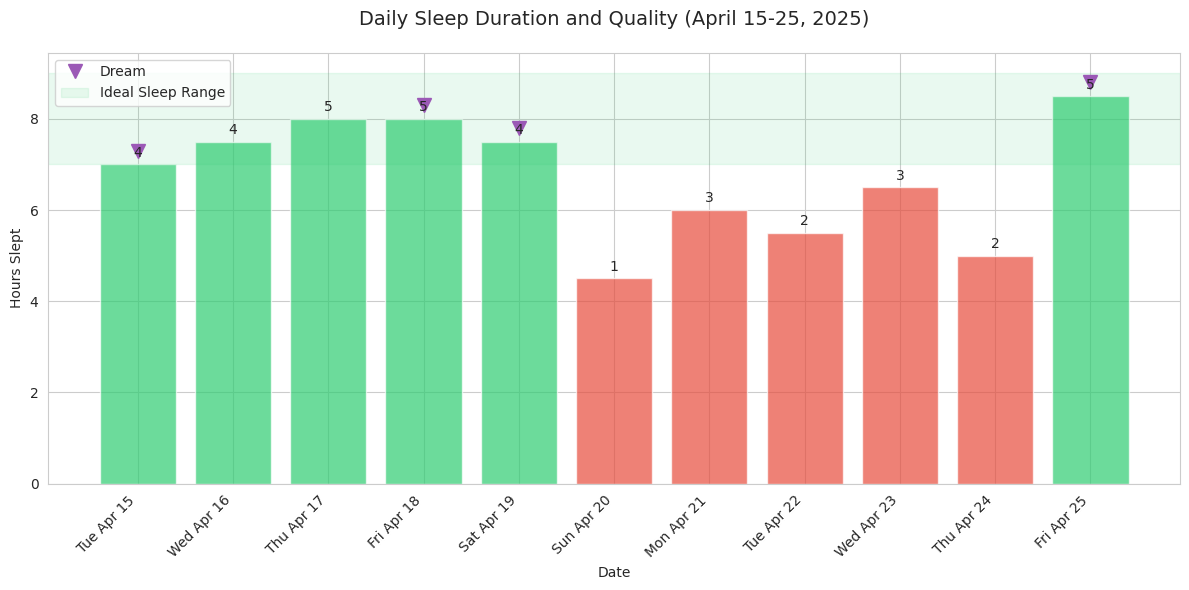

<ipython-input-15-a9438193dd15>:64: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(row['Sleep Duration Hours'], row['Sleep Rating'],


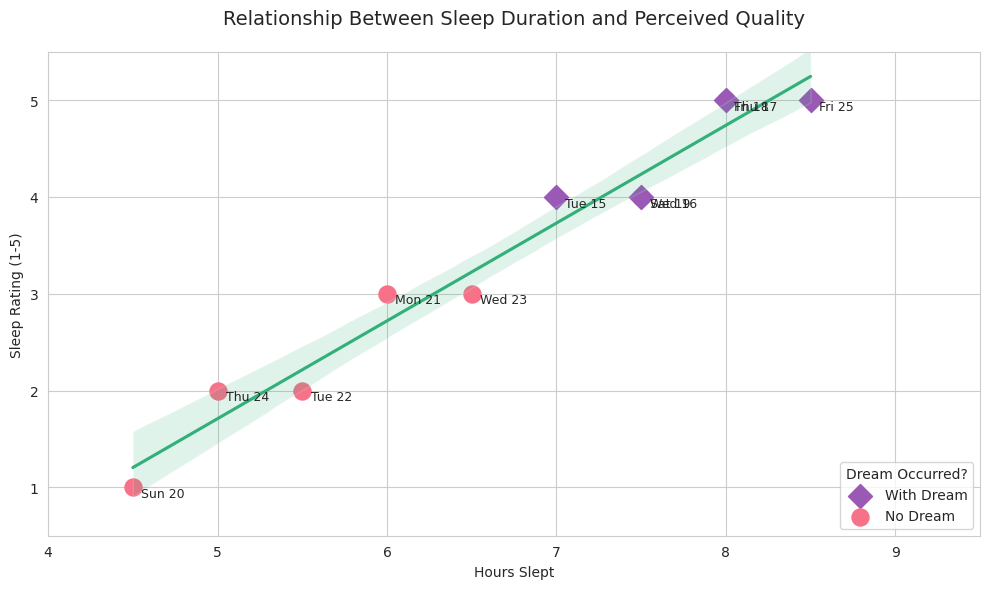

<ipython-input-15-a9438193dd15>:91: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Dream', y='Sleep Duration Hours', data=df, ci=None,


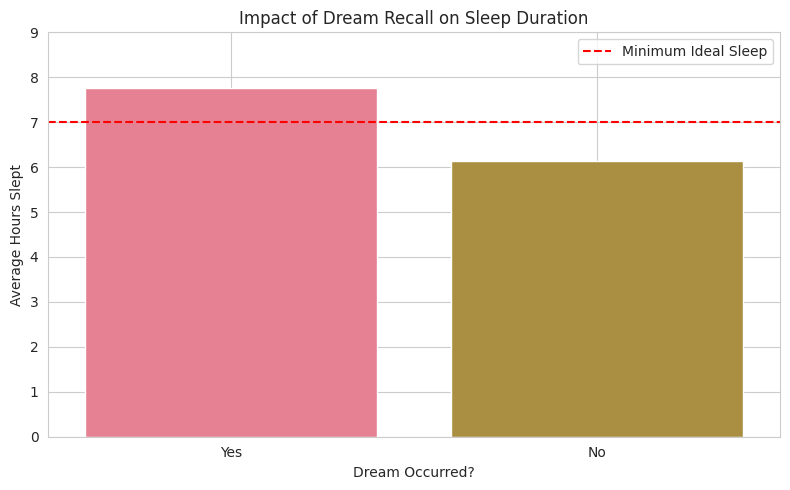

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.dates import DateFormatter, DayLocator

# Load the data
data = {
    'Date': ['2025-04-15', '2025-04-16', '2025-04-17', '2025-04-18', '2025-04-19',
             '2025-04-20', '2025-04-21', '2025-04-22', '2025-04-23', '2025-04-24', '2025-04-25'],
    'Sleep Duration Hours': [7, 7.5, 8, 8, 7.5, 4.5, 6, 5.5, 6.5, 5, 8.5],
    'Ideal sleep Hours': ['07-09']*11,
    'Dream': ['Yes', 'No', 'No', 'Yes', 'Yes', 'No', 'No', 'No', 'No', 'No', 'Yes'],
    'Sleep Rating': [4, 4, 5, 5, 4, 1, 3, 2, 3, 2, 5]
}

df = pd.DataFrame(data)
df['Date'] = pd.to_datetime(df['Date'])
df['Day'] = df['Date'].dt.day_name()
df['Met Ideal Sleep'] = df['Sleep Duration Hours'].apply(lambda x: 'Yes' if 7 <= x <= 9 else 'No')

# Set style
sns.set_style("whitegrid")
palette = sns.color_palette("husl", 5)
ideal_color = '#2ecc71'
non_ideal_color = '#e74c3c'
dream_color = '#9b59b6'

# FIRST PLOT: Sleep Duration Analysis
plt.figure(figsize=(12, 6))
bar_colors = [ideal_color if met == 'Yes' else non_ideal_color for met in df['Met Ideal Sleep']]
bars = plt.bar(df['Date'], df['Sleep Duration Hours'], color=bar_colors, alpha=0.7)

# Add dream indicators
for i, row in df.iterrows():
    if row['Dream'] == 'Yes':
        plt.plot(row['Date'], row['Sleep Duration Hours'] + 0.3,
                'v', color=dream_color, markersize=10, label='Dream' if i == 0 else "")

# Add rating numbers
for i, row in df.iterrows():
    plt.text(row['Date'], row['Sleep Duration Hours'] + 0.1,
            str(row['Sleep Rating']), ha='center', va='bottom')

plt.axhspan(7, 9, alpha=0.1, color=ideal_color, label='Ideal Sleep Range')
plt.title('Daily Sleep Duration and Quality (April 15-25, 2025)', pad=20, fontsize=14)
plt.ylabel('Hours Slept')
plt.xlabel('Date')
plt.legend(loc='upper left')
plt.grid(True)
date_format = DateFormatter("%a %b %d")
plt.gca().xaxis.set_major_formatter(date_format)
plt.gca().xaxis.set_major_locator(DayLocator())
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('sleep_duration_analysis.png', bbox_inches='tight', dpi=300)
plt.show()

# SECOND PLOT: Sleep Quality Analysis
plt.figure(figsize=(10, 6))
for i, row in df.iterrows():
    marker = 'D' if row['Dream'] == 'Yes' else 'o'
    color = dream_color if row['Dream'] == 'Yes' else palette[0]
    plt.scatter(row['Sleep Duration Hours'], row['Sleep Rating'],
               s=150, c=color, marker=marker,
               label='With Dream' if row['Dream'] == 'Yes' and i == 0 else
                     'No Dream' if row['Dream'] == 'No' and i == 1 else "")

# Add regression line
sns.regplot(x='Sleep Duration Hours', y='Sleep Rating', data=df,
            scatter=False, color=palette[2])

# Add data labels
for i, row in df.iterrows():
    plt.text(row['Sleep Duration Hours']+0.05, row['Sleep Rating']-0.1,
            f"{row['Day'][:3]} {row['Date'].day}", fontsize=9)

plt.title('Relationship Between Sleep Duration and Perceived Quality', pad=20, fontsize=14)
plt.xlabel('Hours Slept')
plt.ylabel('Sleep Rating (1-5)')
plt.xlim(4, 9.5)
plt.ylim(0.5, 5.5)
plt.legend(title='Dream Occurred?', loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.savefig('sleep_quality_analysis.png', bbox_inches='tight', dpi=300)
plt.show()

# THIRD PLOT: Dream Impact Analysis
plt.figure(figsize=(8, 5))
sns.barplot(x='Dream', y='Sleep Duration Hours', data=df, ci=None,
            estimator=np.mean, hue='Dream', dodge=False)
plt.title('Impact of Dream Recall on Sleep Duration')
plt.xlabel('Dream Occurred?')
plt.ylabel('Average Hours Slept')
plt.ylim(0, 9)
plt.axhline(y=7, color='red', linestyle='--', label='Minimum Ideal Sleep')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('dream_impact_analysis.png', bbox_inches='tight', dpi=300)
plt.show()

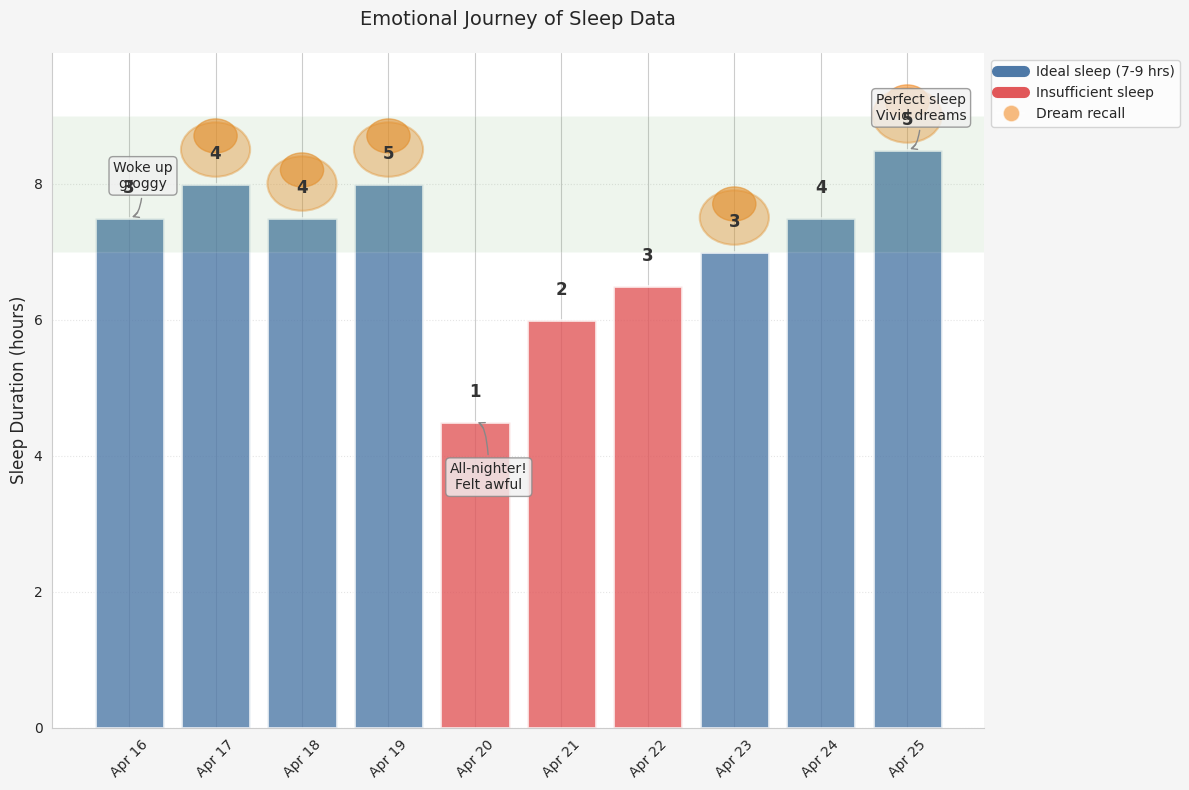

Plot saved as 'creative_representation.png'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<Figure size 640x480 with 0 Axes>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import matplotlib as mpl

# Set up the backend and style
%matplotlib inline
mpl.rcParams['figure.facecolor'] = 'white'

# Your data (replace with your actual data)
dates = ['Apr 16', 'Apr 17', 'Apr 18', 'Apr 19', 'Apr 20',
         'Apr 21', 'Apr 22', 'Apr 23', 'Apr 24', 'Apr 25']
sleep_hours = [7.5, 8.0, 7.5, 8.0, 4.5, 6.0, 6.5, 7.0, 7.5, 8.5]
ratings = [3, 4, 4, 5, 1, 2, 3, 3, 4, 5]
dreams = [False, True, True, True, False, False, False, True, False, True]

# Create figure
fig, ax = plt.subplots(figsize=(12, 8), dpi=100)
fig.patch.set_facecolor('#f5f5f5')

# Draw bars with conditional coloring
bars = ax.bar(dates, sleep_hours,
              color=['#4e79a7' if 7 <= h <= 9 else '#e15759' for h in sleep_hours],
              edgecolor='white', linewidth=2, alpha=0.8)

# Add dream clouds
for i, (dream, hour) in enumerate(zip(dreams, sleep_hours)):
    if dream:
        # Main cloud
        cloud = Ellipse((i, hour + 0.5), width=0.8, height=0.8,
                       facecolor='#f28e2b', alpha=0.4, edgecolor='#f28e2b', linewidth=1.5)
        ax.add_patch(cloud)

        # Inner cloud
        inner_cloud = Ellipse((i, hour + 0.7), width=0.5, height=0.5,
                            facecolor='#f28e2b', alpha=0.6, edgecolor='#f28e2b', linewidth=1)
        ax.add_patch(inner_cloud)

# Add annotations
annotations = {
    0: "Woke up\ngroggy",
    4: "All-nighter!\nFelt awful",
    9: "Perfect sleep\nVivid dreams"
}

for idx, text in annotations.items():
    ax.annotate(text, xy=(idx, sleep_hours[idx]),
                xytext=(10, 30 if idx!=4 else -40), textcoords='offset points',
                ha='center', va='center', fontsize=10,
                bbox=dict(boxstyle="round,pad=0.3", fc="#f0f0f0", ec="#888888", lw=1, alpha=0.8),
                arrowprops=dict(arrowstyle="->", connectionstyle="angle3", color="#888888"))

# Add ideal sleep range
ax.axhspan(7, 9, facecolor='#59a14f', alpha=0.1)

# Add ratings
for i, rating in enumerate(ratings):
    ax.text(i, sleep_hours[i] + 0.3, str(rating), ha='center', va='bottom',
            fontsize=12, fontweight='bold', color='#333333')

# Customize plot
ax.set_ylabel('Sleep Duration (hours)', fontsize=12)
ax.set_title('Emotional Journey of Sleep Data', fontsize=14, pad=20)
ax.tick_params(axis='x', rotation=45)

# Create legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='#4e79a7', lw=8, label='Ideal sleep (7-9 hrs)'),
    Line2D([0], [0], color='#e15759', lw=8, label='Insufficient sleep'),
    Line2D([0], [0], marker='o', color='w', label='Dream recall',
           markerfacecolor='#f28e2b', markersize=12, alpha=0.6)
]
ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1, 1))

# Style adjustments
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', linestyle=':', alpha=0.5)

plt.tight_layout()

# Show and save
plt.show()

# Save to file (in Colab this will save to your virtual machine)
plt.savefig('creative_representation.png', bbox_inches='tight', dpi=120)
print("Plot saved as 'creative_representation.png'")

# To download the file in Colab
from google.colab import files
files.download('creative_representation.png')